# 第 10 章 · 真实照片卷积代码实验

本页用真实花朵照片观察卷积核如何提取边缘。读者先看原图和卷积核，再看局部窗口的计算值，最后看池化如何压缩特征图。

[章节网页](../ch10.html)

## 运行内容

- 加载真实照片
- 计算 Sobel 卷积
- 绘制边缘特征图

## 0. 图像与卷积核

输入图像来自真实照片，Sobel 核会强调竖向边缘。卷积输出越大，表示该区域越像这个边缘模式。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import contextlib
import io
import logging
import math
import os
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]

os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
os.environ.setdefault("DIFFUSERS_VERBOSITY", "error")

def install_packages(packages):
    if not packages:
        return
    command = [sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check", *packages]
    try:
        subprocess.check_call(command, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError("依赖安装失败，请检查网络后重新运行本单元。") from exc

install_packages(missing)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("diffusers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 使用真实花朵照片，配合 Sobel 核做边缘检测。
raw_conv_photo = load_sample_image("flower.jpg")
conv_photo = np.asarray(Image.fromarray(raw_conv_photo).resize((96, 96))) / 255.0
image = np.dot(conv_photo[..., :3], [0.299, 0.587, 0.114])
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype=float)

feature = correlate2d(image, kernel, mode="valid")
display(pd.DataFrame({
    "图像": ["flower.jpg"],
    "尺寸": [f"{image.shape[0]}x{image.shape[1]}"],
    "灰度最小值": [float(image.min())],
    "灰度最大值": [float(image.max())],
}).round(3))
display(pd.DataFrame(kernel.astype(int)))

,图像,尺寸,灰度最小值,灰度最大值
0,flower.jpg,96x96,0.024,0.851


,0,1,2
0,-1,0,1
1,-1,0,1
2,-1,0,1


## 1. 卷积与池化

卷积逐窗口计算局部模式，池化保留局部最强响应。把三张图连起来看，能看到图像如何逐步变成特征。

In [3]:
# 展开中心区域的几个窗口，观察卷积值如何来自局部像素。
rows = []
for i in range(40, 46):
    for j in range(40, 46):
        window = image[i:i + 3, j:j + 3]
        rows.append({
            "位置": f"({i},{j})",
            "窗口均值": window.mean(),
            "左列均值": window[:, 0].mean(),
            "右列均值": window[:, 2].mean(),
            "卷积值": round(float((window * kernel).sum()), 3),
        })

conv_df = pd.DataFrame(rows)
display(conv_df.head(10).round(3))
display(pd.DataFrame({
    "特征图尺寸": [f"{feature.shape[0]}x{feature.shape[1]}"],
    "最小响应": [float(feature.min())],
    "最大响应": [float(feature.max())],
    "平均绝对响应": [float(np.abs(feature).mean())],
}).round(3))

,位置,窗口均值,左列均值,右列均值,卷积值
0,"(40,40)",0.404,0.441,0.356,-0.255
1,"(40,41)",0.353,0.415,0.289,-0.379
2,"(40,42)",0.369,0.356,0.462,0.318
3,"(40,43)",0.361,0.289,0.332,0.132
4,"(40,44)",0.373,0.462,0.325,-0.410
5,"(40,45)",0.320,0.332,0.302,-0.092
6,"(41,40)",0.380,0.415,0.335,-0.239
7,"(41,41)",0.324,0.391,0.247,-0.432
8,"(41,42)",0.332,0.335,0.413,0.236
9,"(41,43)",0.295,0.247,0.223,-0.073


,特征图尺寸,最小响应,最大响应,平均绝对响应
0,94x94,-2.107,1.838,0.137


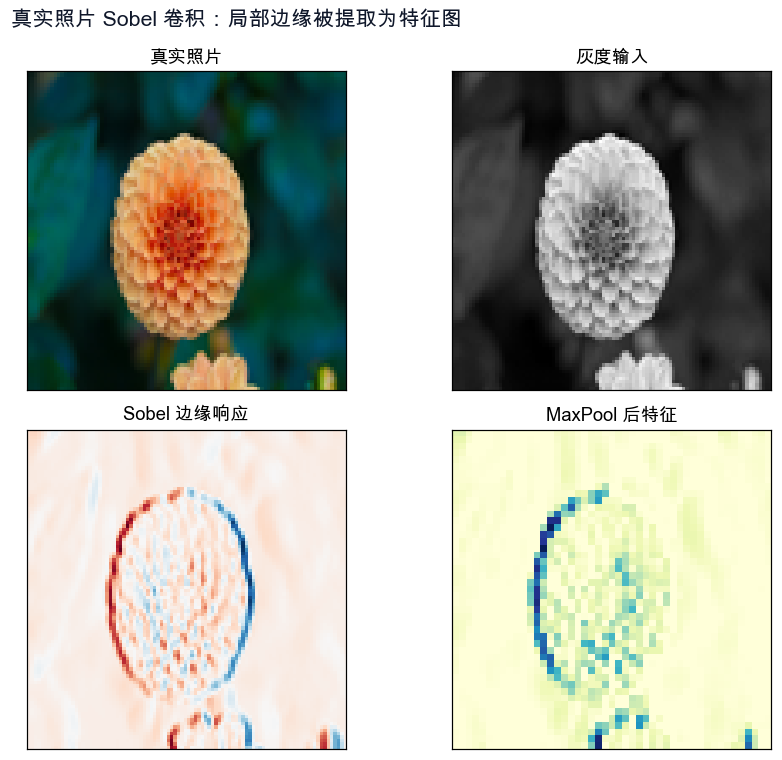

In [4]:
# 绘制输入、边缘响应和 2x2 max pooling。
positive_feature = np.maximum(feature, 0)
pool = np.array([
    [positive_feature[i:i + 2, j:j + 2].max() for j in range(0, positive_feature.shape[1] - 1, 2)]
    for i in range(0, positive_feature.shape[0] - 1, 2)
])

fig, axes = plt.subplots(2, 2, figsize=(8.4, 7.0))
for ax, data, title, cmap in zip(
    axes.ravel(),
    [conv_photo, image, feature, pool],
    ["真实照片", "灰度输入", "Sobel 边缘响应", "MaxPool 后特征"],
    [None, "gray", "RdBu_r", "YlGnBu"],
):
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("真实照片 Sobel 卷积：局部边缘被提取为特征图", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()